<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_14%EC%B0%A8%EC%8B%9C_01_%EC%A0%84%EC%9D%B4%ED%95%99%EC%8A%B5_%EC%8B%A4%EC%8A%B5_%EC%84%B9%EC%85%98%EB%B3%84%5Blive%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 전이학습 전략 비교 실습

이 실습에서는 **3가지 전이학습 전략**을 비교합니다:
1. **Freeze (전체 동결)**: 백본 전체를 고정하고 분류기만 학습
2. **Partial (부분 해제)**: 마지막 블록(layer4)과 분류기만 학습
3. **Full (전체 해제)**: 모든 층을 학습

**목표**: 소규모 데이터셋(3,000개)에서 각 전략의 성능을 비교하고 최적 전략을 찾기

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

런타임 다시 시작하세요

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 나눔고딕 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# matplotlib 기본 폰트로 지정
matplotlib.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료:", matplotlib.rcParams['font.family'])

한글 폰트 설정 완료: ['NanumGothic']


In [2]:
# 필수 라이브러리 임포트
import torch  # PyTorch 메인 라이브러리
import torch.nn as nn  # 신경망 모듈
import torch.optim as optim  # 최적화 알고리즘
from torchvision import datasets, transforms, models  # 비전 관련 도구
from torch.utils.data import DataLoader, Subset  # 데이터 로더
import numpy as np  # 수치 연산
import random  # 랜덤 함수

# GPU 사용 가능 여부 확인 및 디바이스 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 디바이스: {device}')

# 재현성을 위한 시드 설정 (매번 동일한 결과를 얻기 위함)
torch.manual_seed(0)  # PyTorch 시드
np.random.seed(0)  # NumPy 시드
random.seed(0)  # Python random 시드

# CUDA 사용 시 추가 재현성 설정
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)  # CUDA 시드
    torch.backends.cudnn.deterministic = True  # 결정적 알고리즘 사용
    torch.backends.cudnn.benchmark = False  # 벤치마크 비활성화

print('환경 설정 완료!')
print(f'PyTorch 버전: {torch.__version__}')

사용 디바이스: cuda
환경 설정 완료!
PyTorch 버전: 2.10.0+cu128


데이터 전처리

In [3]:
transform_train = \
transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6,1.0)),
    # 이미지 60~100% 랜덤으로 224*224 크기로 자름
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    transforms.Normalize(mean = (0.482, 0.456, 0.405),
                         std = (0.229, 0.234, 0.225))
])

transform_test = \
transforms.Compose([
    transforms.Resize(256),
    # 이미지를 256*256
    transforms.CenterCrop(224),
    # 중앙을 24*224 이미지로 잘라냄 (증강 없이 고정된 영역 사용)

    transforms.ToTensor(),
    transforms.Normalize(mean = (0.482, 0.456, 0.405),
                         std = (0.229, 0.234, 0.225))
])

In [4]:
dataset_train_full =  datasets.CIFAR10(
                      root = '/tmp/cifar.tl',
                      train = True,
                      download=True,
                      transform = transform_train
                  )

dataset_test =  datasets.CIFAR10(
                      root = '/tmp/cifar.tl',
                      train = False,
                      download=True,
                      transform = transform_test
                  )

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


In [5]:
print(f'전체 학습 데이터: {len(dataset_train_full):,}개')
print(f'전체 테스트 데이터: {len(dataset_test):,}개')
print(f'클래스 수: 10개 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)')

전체 학습 데이터: 50,000개
전체 테스트 데이터: 10,000개
클래스 수: 10개 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)


소규모 서브셋 생성

- 전체 50000개 중 각 클래스 당 300씩, 총 3000개만 사용하여 소규모 데이터 셋 상황 어떻게 해결할 것인다?`

In [6]:
# 각 클래스 별로 300개씩 선택 >> 총 3000개 서브셋 생성

selcted_indices = []

# 각 클래스 (0-9) 별로 카운트 저장할 딕셔너리 초기화
class_counts = {i : 0 for i in range(10)}
# print(class_counts)

# 전체 학습 데이처 돌연사 각 클래스 당 3000개씩 선택
for idx, (image, label) in enumerate(dataset_train_full):
    # 조건 1 : 해당 클래스 현재 개수가 300개 미만이면
    if class_counts[label] < 300:
        selcted_indices.append(idx)
        class_counts[label] += 1

    # 조건 2 : 중지조건
    # 총 3000개 모두 선택하면 중지
    if len(selcted_indices) == 3000:
        break

# print(selcted_indices)
# print(len(selcted_indices))

# 선택된 인덱스 >> 서브셋 생성

dataset_train_small = Subset(dataset_train_full, selcted_indices)

print(len(dataset_train_small))

3000


In [7]:
# class_counts
for class_id, count in class_counts.items():
  class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog','frog','horse','ship','truck'][class_id]
  print(f'{class_id} ({class_name}): {count}개')

0 (airplane): 300개
1 (automobile): 300개
2 (bird): 300개
3 (cat): 300개
4 (deer): 300개
5 (dog): 300개
6 (frog): 300개
7 (horse): 300개
8 (ship): 300개
9 (truck): 300개


데이터 로더 생성

In [8]:
train_loader =  DataLoader(
                dataset_train_small,
                batch_size = 64,
                shuffle=True,
                # 한번 학습할 때 마다(매 epoch) 무작위 데이터 순서를 섞어줌 (과적합 방지)
                num_workers=2,
                pin_memory=True
            )

test_loader =  DataLoader(
                dataset_train_small,
                batch_size = 128,
                shuffle=False,
                num_workers=2,
                pin_memory=True
            )


In [9]:
# 데이터 로더 정보 출력
print(f'\n학습 데이터:')
print(f'  - 총 샘플 수: {len(dataset_train_small):,}개')
print(f'  - 배치 크기: 64')
print(f'  - 배치 수: {len(train_loader)}개')
print(f'\n테스트 데이터:')
print(f'  - 총 샘플 수: {len(dataset_test):,}개')
print(f'  - 배치 크기: 128')
print(f'  - 배치 수: {len(test_loader)}개')


학습 데이터:
  - 총 샘플 수: 3,000개
  - 배치 크기: 64
  - 배치 수: 47개

테스트 데이터:
  - 총 샘플 수: 10,000개
  - 배치 크기: 128
  - 배치 수: 24개


모델 빌드 함수 정의

In [28]:
# 3가지 전략 (freeze, partial, full)

def build_model(strategy = 'freeze'):
    # 모델 인스턴스를 'model' 변수에 할당
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # 사전 학습된 모델의 가중치 사용 (ResNet18에 맞는 가중치 사용)

    # 원래 resnet18의 분류기 입력 특징 차원 저장
    in_features = model.fc.in_features # 512 차원 (할당된 model 인스턴스에서 접근)

    # 분류기를 CIFAR10에 맞게 교체 (1000클래스 분류기 >> 10클래스 분류기)
    model.fc = nn.Linear(in_features, 10)

    # 전략에 따라 파라미터 동결 설정
    if strategy == 'freeze':
        # 전략 1 백본 전체 동결 >> 분류기만 학습하는 전략
        print('[Freeze 전략]:백본 전체 동결 >> 분류기만 학습')

        # layer 1,2,3,4 전체 동결시킴
        for param in model.layer1.parameters():
            param.requires_grad = False
            # 기울기(gradient) 계산 비활성화

        for param in model.layer2.parameters():
            param.requires_grad = False

        for param in model.layer3.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = False

    elif strategy == 'partial':
        # 전략 2 : 마지막 블록(layer4) 과 분류기만 학습
        print('[Partial 전략]:마지막 블록(layer4)과 분류기 학습')

        # 먼저 모든 파라미터 동결
        for param in model.parameters():
            param.requires_grad = False

        # layer4와 fc(분류기)만 해제(학습시킴)
        for param in model.layer4.parameters():
            param.requires_grad = True  # 기울기 계산 활성화
        for param in model.fc.parameters():
            param.requires_grad = True

    elif strategy == 'full':
        # 전략 3 : 모든 층 다시 학습
        print('[Full 전략]:모든 층 학습')

        for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError('지원되지 않는 전략입니다')

    model = model.to(device)

    # 학습 가능한 파라미터 수 계산
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'학습 가능한 파라미터:{trainable_params:,}/{total_params:,}')

    return model

학습 및 평가 함수 정의

In [17]:
def train_and_evaluate(strategy):

    # 1. 전략에 맞는 모델 생성
    model = build_model(strategy)

    # 2. 최적화 함수 설정(차등학습률 적용)
    # 헤드(분류기)와 백본 파라미터 분리
    head_params = list(model.fc.parameters())
    # 분류기 파라미터
    # print(head_params) # 이 줄은 디버깅용으로, 주석 처리하거나 필요에 따라 사용하세요.

    # 백본 파라미터 (fc 아니면서 학습 가능한 파라미터)
    backbone_params = [param for name, param in model.named_parameters()
                       if 'fc' not in name and param.requires_grad]

    # 파라미터 그룹 구성 (차등 학습률)
    params_groups = []

    # 백본 파라미터 있다면
    if backbone_params:
        params_groups.append({
            'params': backbone_params,
            'lr': 1e-4
            # 백본 낮은 학습률 (0.0001)
        })

    # 헤드(분류기) 파라미터가 있다면
    if head_params:
        params_groups.append({
            'params': head_params,
            'lr': 1e-3
            # 헤드(분류기) 높은 학습률 (0.001, 백본의 10배)
        })

    # AdamW 옵티마이저 사용 (가중치 감쇠 weight_decay : L2 규제 포함)
    optimizer = optim.AdamW(params_groups, weight_decay=1e-4)

    # 손실함수 정의
    criterion = nn.CrossEntropyLoss() # 'critetion' -> 'criterion' 오타 수정

    # 학습 루프
    num_epochs = 10

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0 # 에폭별 손실 누적
        correct = 0     # 맞춘 개수
        total = 0       # 전체 샘플 수

        # 배치 별 학습
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # gradient 초기화
            optimizer.zero_grad()

            # 순전파 학습
            outputs = model(inputs)

            # 손실계산
            loss = criterion(outputs, labels)

            # 역전파
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            # 통계 업데이트
            running_loss += loss.item() * inputs.size(0) # 누락된 running_loss 업데이트 추가
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # 에폭별 결과 출력
        epoch_loss = running_loss / total
        epoch_acc = 100.0 * correct / total
        print(f'Epoch [{epoch + 1} / {num_epochs}] '
              f'Loss: {epoch_loss:.4f}, '
              f'Train_Acc: {epoch_acc:.2f}%')

        model.eval()    # 평가 모드로 전환

        correct = 0
        total = 0

        # gradient 계산 비활성화
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 순전파
                outputs = model(inputs)

                #에측값 계산
                predicted = outputs.argmax(dim=1)

                # 정확도 계산
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        # 최종 테스트 정확도 계산
        test_accuracy = correct / total

        print(f'테스트 정확도:{test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

    return test_accuracy

실험 1 : Freeze (전체 동결)

In [18]:
acc_freeze = train_and_evaluate('freeze')

[Freeze 전략]:백본 전체 동결 >> 분류기만 학습
학습 가능한 파라미터:14,666/11,181,642
Epoch [1 / 10] Loss: 1.8651, Train_Acc: 36.80%
테스트 정확도:0.5783 (57.83%)
Epoch [2 / 10] Loss: 1.2657, Train_Acc: 62.73%
테스트 정확도:0.6883 (68.83%)
Epoch [3 / 10] Loss: 1.0231, Train_Acc: 69.33%
테스트 정확도:0.7037 (70.37%)
Epoch [4 / 10] Loss: 0.9362, Train_Acc: 70.07%
테스트 정확도:0.7367 (73.67%)
Epoch [5 / 10] Loss: 0.8434, Train_Acc: 74.07%
테스트 정확도:0.7437 (74.37%)
Epoch [6 / 10] Loss: 0.8071, Train_Acc: 74.63%
테스트 정확도:0.7490 (74.90%)
Epoch [7 / 10] Loss: 0.7673, Train_Acc: 74.67%
테스트 정확도:0.7723 (77.23%)
Epoch [8 / 10] Loss: 0.7438, Train_Acc: 75.87%
테스트 정확도:0.7883 (78.83%)
Epoch [9 / 10] Loss: 0.7149, Train_Acc: 76.67%
테스트 정확도:0.7840 (78.40%)
Epoch [10 / 10] Loss: 0.6882, Train_Acc: 76.47%
테스트 정확도:0.7930 (79.30%)


실험 2 : Partial (부분 동결)

In [19]:
acc_partial = train_and_evaluate('partial')

[Partial 전략]:마지막 블록(layer4)과 분류기 학습
학습 가능한 파라미터:8,398,858/11,181,642
Epoch [1 / 10] Loss: 1.2056, Train_Acc: 58.73%
테스트 정확도:0.8043 (80.43%)
Epoch [2 / 10] Loss: 0.5754, Train_Acc: 81.07%
테스트 정확도:0.8687 (86.87%)
Epoch [3 / 10] Loss: 0.4169, Train_Acc: 85.43%
테스트 정확도:0.9060 (90.60%)
Epoch [4 / 10] Loss: 0.3134, Train_Acc: 89.03%
테스트 정확도:0.9393 (93.93%)
Epoch [5 / 10] Loss: 0.2681, Train_Acc: 91.30%
테스트 정확도:0.9583 (95.83%)
Epoch [6 / 10] Loss: 0.1917, Train_Acc: 93.80%
테스트 정확도:0.9683 (96.83%)
Epoch [7 / 10] Loss: 0.1629, Train_Acc: 95.00%
테스트 정확도:0.9700 (97.00%)
Epoch [8 / 10] Loss: 0.1242, Train_Acc: 96.47%
테스트 정확도:0.9707 (97.07%)
Epoch [9 / 10] Loss: 0.1119, Train_Acc: 96.73%
테스트 정확도:0.9787 (97.87%)
Epoch [10 / 10] Loss: 0.0980, Train_Acc: 96.80%
테스트 정확도:0.9820 (98.20%)


실험 3 : Full (전체 학습)

In [20]:
acc_full = train_and_evaluate('full')

[Full 전략]:모든 층 학습
학습 가능한 파라미터:11,181,642/11,181,642
Epoch [1 / 10] Loss: 1.1165, Train_Acc: 62.73%
테스트 정확도:0.8497 (84.97%)
Epoch [2 / 10] Loss: 0.4277, Train_Acc: 85.97%
테스트 정확도:0.9270 (92.70%)
Epoch [3 / 10] Loss: 0.2459, Train_Acc: 92.63%
테스트 정확도:0.9443 (94.43%)
Epoch [4 / 10] Loss: 0.1620, Train_Acc: 95.23%
테스트 정확도:0.9653 (96.53%)
Epoch [5 / 10] Loss: 0.1237, Train_Acc: 96.53%
테스트 정확도:0.9760 (97.60%)
Epoch [6 / 10] Loss: 0.0977, Train_Acc: 97.10%
테스트 정확도:0.9813 (98.13%)
Epoch [7 / 10] Loss: 0.0670, Train_Acc: 97.70%
테스트 정확도:0.9860 (98.60%)
Epoch [8 / 10] Loss: 0.0680, Train_Acc: 97.90%
테스트 정확도:0.9913 (99.13%)
Epoch [9 / 10] Loss: 0.0589, Train_Acc: 98.23%
테스트 정확도:0.9907 (99.07%)
Epoch [10 / 10] Loss: 0.0597, Train_Acc: 98.13%
테스트 정확도:0.9883 (98.83%)


최종 결과 비교 및 분석

In [21]:
results = {
    'Freeze (백본 전체 동결)': acc_freeze,
    'Partial (layer4, fc 해제)': acc_partial,
    'Full(모든 층 학습)': acc_full
}


print(f'\n{"전략":<30} {"테스트 정확도":>15}')
print('='*70)


for strategy_name, accuracy in results.items():
    print(f'{strategy_name:<30} {accuracy*100:>14.2f}%')


전략                                     테스트 정확도
Freeze (백본 전체 동결)                       79.30%
Partial (layer4, fc 해제)                 98.20%
Full(모든 층 학습)                           98.83%


In [27]:
# 최고 성능 전략 찾기

best_strategy = max(results, key=results.get)
print(best_strategy)

best_acc = results[best_strategy]
print(best_acc)

Full(모든 층 학습)
0.9883333333333333


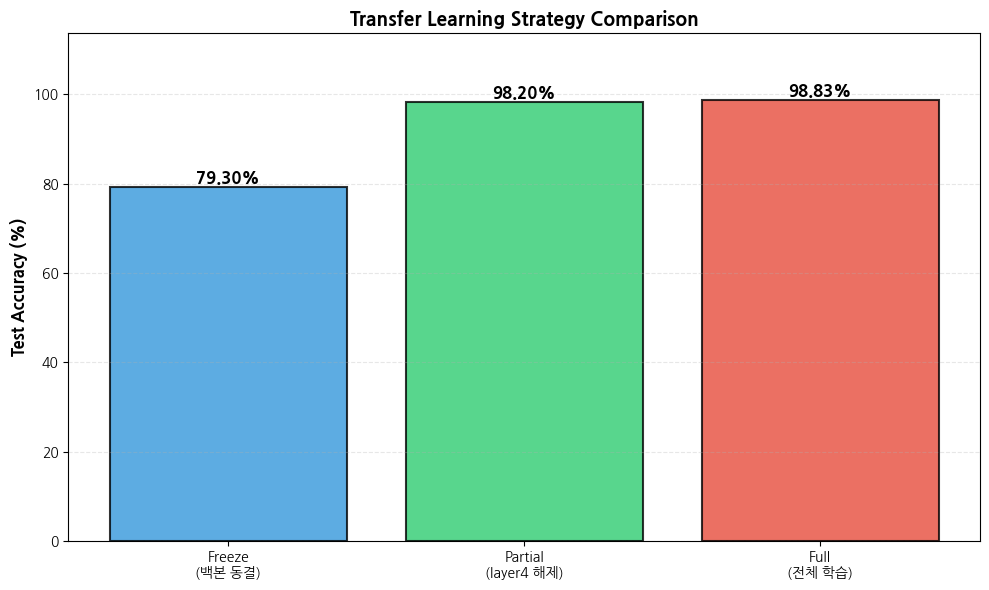

In [25]:
# Matplotlib 라이브러리 임포트
import matplotlib.pyplot as plt


# 전략 이름과 정확도
strategies = ['Freeze\n(백본 동결)', 'Partial\n(layer4 해제)', 'Full\n(전체 학습)']
accuracies = [acc_freeze * 100, acc_partial * 100, acc_full * 100]


# 막대 그래프 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(strategies, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'],
               alpha=0.8, edgecolor='black', linewidth=1.5)


# 각 막대 위에 정확도 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')


# 그래프 설정
plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Transfer Learning Strategy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, max(accuracies) * 1.15])  # Y축 범위 설정
plt.grid(True, axis='y', alpha=0.3, linestyle='--')


# 그래프 표시
plt.tight_layout()
plt.show()